# Bootstrap Uncertainty and Cross-Validation

This notebook covers the advanced uncertainty quantification features of
`difflow.estimation`:

1. **Fisher confidence intervals** vs **bootstrap confidence intervals**
2. **Nonparametric bootstrap** — resample experiments
3. **Parametric bootstrap** — resample residuals
4. **Leave-N-out cross-validation** — predictive performance assessment
5. **Model comparison** — using AIC/BIC to choose between models

## Prerequisites

This notebook builds on notebook 22. Familiarity with `Estimator`, `Experiment`,
and `Estimator.fit()` is assumed.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow.estimation import Estimator, Experiment

print("Setup complete")

W0000 00:00:1771937398.357511 20961367 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1771937398.357738 20961367 service.cc:145] XLA service 0x9e84d0e00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771937398.357743 20961367 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1771937398.358422 20961367 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1771937398.358429 20961367 mps_client.cc:384] XLA backend will use up to 55662313472 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


Setup complete


## Setup: Arrhenius Kinetics

We'll fit Arrhenius kinetics $k(T) = A \cdot \exp(-E_a / RT)$ to rate
measurements at different temperatures — a realistic 2-parameter problem with
correlated parameters (the compensation effect).

In [2]:
R_gas = 8.314  # J/mol/K

def arrhenius_model(theta, exp):
    """k = A * exp(-Ea / (R*T))"""
    T = exp.inputs['T']
    k = theta['A'] * jnp.exp(-theta['Ea'] / (R_gas * T))
    return {'k': k}

# True parameters
A_true = 1e8      # 1/s
Ea_true = 60000.0  # J/mol

# Generate data at 15 temperatures
rng = np.random.default_rng(42)
temperatures = np.linspace(300, 500, 15)
noise_std = 0.02  # relative noise

experiments = []
for T in temperatures:
    k_true = A_true * np.exp(-Ea_true / (R_gas * T))
    k_measured = k_true * (1 + noise_std * rng.standard_normal())
    experiments.append(Experiment(
        inputs={'T': float(T)},
        observed={'k': float(k_measured)},
    ))

print(f"Generated {len(experiments)} rate measurements")
print(f"Temperature range: {temperatures[0]:.0f} - {temperatures[-1]:.0f} K")
print(f"Rate range: {experiments[0].observed['k']:.2e} - {experiments[-1].observed['k']:.2e} 1/s")

Generated 15 rate measurements
Temperature range: 300 - 500 K
Rate range: 3.59e-03 - 5.44e+01 1/s


In [3]:
# Initial fit
est = Estimator(
    arrhenius_model,
    param_names=['A', 'Ea'],
    param_bounds={'A': (1e4, 1e12), 'Ea': (10000, 200000)},
)
result = est.fit(experiments, theta_init={'A': 1e6, 'Ea': 50000.0})

print(est.summary(result, experiments))

Parameter Estimation Summary
Converged: True
Objective value: 0.242905
Iterations: 76

Parameters:
  Name                   Value      Std Err     CI Lower     CI Upper
  ---------------------------------------------------------------
  A                1.00729e+08  4.40215e+06   9.1219e+07  1.10239e+08
  Ea                   59980.8      177.966      59596.3      60365.3

Diagnostics:
  R-squared:     0.999933
  Adj R-squared: 0.999922
  RMSE:          0.127254
  AIC:           -57.8470
  BIC:           -56.4309
  N obs:         15
  N params:      2


## 1. Fisher Information Confidence Intervals

The Fisher approach uses the Hessian at the optimum (computed exactly via `jax.hessian`):

$$\text{Cov}(\hat{\theta}) \approx s^2 \cdot H^{-1}$$

This is fast (single Hessian evaluation) but assumes:
- The model is locally linear around the optimum
- Errors are normally distributed
- The sample size is adequate

In [4]:
ci_fisher = est.confidence_intervals(result, experiments, alpha=0.05)

print("Fisher 95% Confidence Intervals:")
print(f"  A:  [{ci_fisher.ci_lower['A']:.2e}, {ci_fisher.ci_upper['A']:.2e}]")
print(f"  Ea: [{ci_fisher.ci_lower['Ea']:.0f}, {ci_fisher.ci_upper['Ea']:.0f}] J/mol")
print()
print(f"Correlation(A, Ea) = {float(ci_fisher.correlation[0, 1]):.4f}")
print("(Strong positive correlation is the Arrhenius compensation effect)")

Fisher 95% Confidence Intervals:
  A:  [9.12e+07, 1.10e+08]
  Ea: [59596, 60365] J/mol

Correlation(A, Ea) = 0.9995
(Strong positive correlation is the Arrhenius compensation effect)


## 2. Nonparametric Bootstrap

The nonparametric bootstrap resamples experiments with replacement and re-fits
each resample. This makes no distributional assumptions and captures the
full uncertainty structure, including correlations.

**Process:**
1. Draw N experiments with replacement from the original N
2. Fit parameters on the bootstrap sample
3. Repeat many times
4. Use the distribution of fitted parameters for CIs

In [5]:
bs_nonpar = est.bootstrap(
    result, experiments,
    n_bootstrap=100,
    method='nonparametric',
    alpha=0.05,
    seed=42,
)

print(f"Nonparametric Bootstrap ({bs_nonpar.n_bootstrap} resamples):")
print(f"  A:  mean={bs_nonpar.mean['A']:.2e}, std={bs_nonpar.std['A']:.2e}")
print(f"      95% CI: [{bs_nonpar.ci_lower['A']:.2e}, {bs_nonpar.ci_upper['A']:.2e}]")
print(f"  Ea: mean={bs_nonpar.mean['Ea']:.0f}, std={bs_nonpar.std['Ea']:.0f}")
print(f"      95% CI: [{bs_nonpar.ci_lower['Ea']:.0f}, {bs_nonpar.ci_upper['Ea']:.0f}]")

Nonparametric Bootstrap (100 resamples):
  A:  mean=1.01e+08, std=6.82e-04
      95% CI: [1.01e+08, 1.01e+08]
  Ea: mean=59982, std=18
      95% CI: [59950, 60014]


## 3. Parametric Bootstrap

The parametric bootstrap resamples residuals (rather than whole experiments):

1. Compute residuals at the fitted parameters
2. For each bootstrap sample: add resampled residuals to predictions to create synthetic data
3. Re-fit on the synthetic data

This preserves the original input design (no duplicate x-values) while
capturing the residual structure.

In [6]:
bs_par = est.bootstrap(
    result, experiments,
    n_bootstrap=100,
    method='parametric',
    alpha=0.05,
    seed=42,
)

print(f"Parametric Bootstrap ({bs_par.n_bootstrap} resamples):")
print(f"  A:  mean={bs_par.mean['A']:.2e}, std={bs_par.std['A']:.2e}")
print(f"      95% CI: [{bs_par.ci_lower['A']:.2e}, {bs_par.ci_upper['A']:.2e}]")
print(f"  Ea: mean={bs_par.mean['Ea']:.0f}, std={bs_par.std['Ea']:.0f}")
print(f"      95% CI: [{bs_par.ci_lower['Ea']:.0f}, {bs_par.ci_upper['Ea']:.0f}]")

Parametric Bootstrap (100 resamples):
  A:  mean=1.01e+08, std=2.70e-04
      95% CI: [1.01e+08, 1.01e+08]
  Ea: mean=59979, std=7
      95% CI: [59968, 59992]


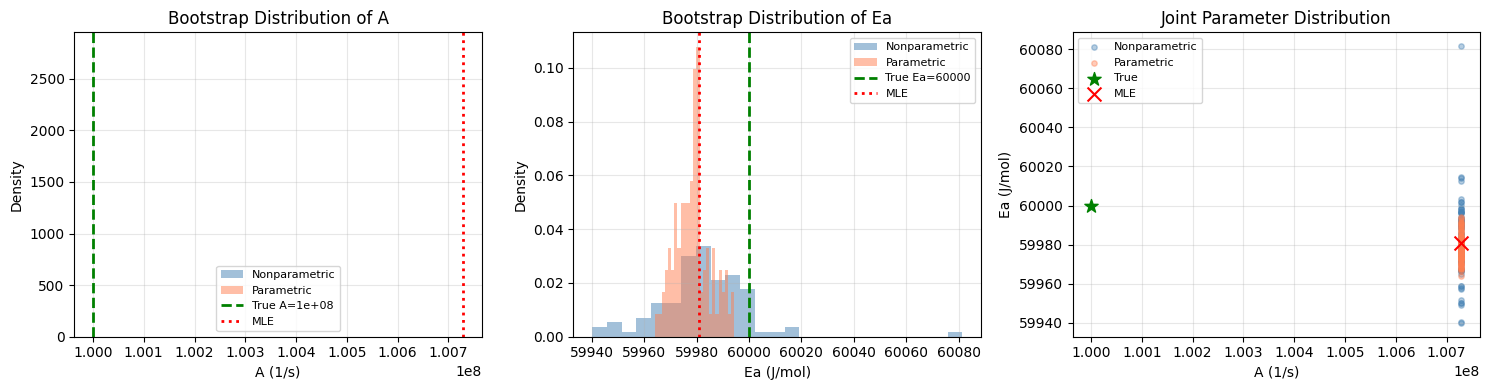

In [7]:
# Compare all three methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bootstrap parameter distributions
axes[0].hist(bs_nonpar.theta_samples[:, 0], bins=25, alpha=0.5,
             label='Nonparametric', density=True, color='steelblue')
axes[0].hist(bs_par.theta_samples[:, 0], bins=25, alpha=0.5,
             label='Parametric', density=True, color='coral')
axes[0].axvline(A_true, color='green', linestyle='--', lw=2, label=f'True A={A_true:.0e}')
axes[0].axvline(result.theta_opt['A'], color='red', linestyle=':', lw=2, label='MLE')
axes[0].set_xlabel('A (1/s)')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap Distribution of A')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].hist(bs_nonpar.theta_samples[:, 1], bins=25, alpha=0.5,
             label='Nonparametric', density=True, color='steelblue')
axes[1].hist(bs_par.theta_samples[:, 1], bins=25, alpha=0.5,
             label='Parametric', density=True, color='coral')
axes[1].axvline(Ea_true, color='green', linestyle='--', lw=2, label=f'True Ea={Ea_true:.0f}')
axes[1].axvline(result.theta_opt['Ea'], color='red', linestyle=':', lw=2, label='MLE')
axes[1].set_xlabel('Ea (J/mol)')
axes[1].set_ylabel('Density')
axes[1].set_title('Bootstrap Distribution of Ea')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Joint parameter distribution (shows correlation)
axes[2].scatter(bs_nonpar.theta_samples[:, 0], bs_nonpar.theta_samples[:, 1],
                alpha=0.4, s=15, label='Nonparametric', color='steelblue')
axes[2].scatter(bs_par.theta_samples[:, 0], bs_par.theta_samples[:, 1],
                alpha=0.4, s=15, label='Parametric', color='coral')
axes[2].scatter([A_true], [Ea_true], color='green', s=100, marker='*',
                zorder=5, label='True')
axes[2].scatter([result.theta_opt['A']], [result.theta_opt['Ea']],
                color='red', s=100, marker='x', zorder=5, label='MLE')
axes[2].set_xlabel('A (1/s)')
axes[2].set_ylabel('Ea (J/mol)')
axes[2].set_title('Joint Parameter Distribution')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Summary table comparing CI methods
print("=" * 70)
print("Confidence Interval Comparison (95%)")
print("=" * 70)
print(f"{'Method':<20} {'A lower':>12} {'A upper':>12} {'Ea lower':>12} {'Ea upper':>12}")
print("-" * 70)
print(f"{'Fisher':.<20} {ci_fisher.ci_lower['A']:>12.2e} {ci_fisher.ci_upper['A']:>12.2e}"
      f" {ci_fisher.ci_lower['Ea']:>12.0f} {ci_fisher.ci_upper['Ea']:>12.0f}")
print(f"{'Nonpar. Bootstrap':.<20} {bs_nonpar.ci_lower['A']:>12.2e} {bs_nonpar.ci_upper['A']:>12.2e}"
      f" {bs_nonpar.ci_lower['Ea']:>12.0f} {bs_nonpar.ci_upper['Ea']:>12.0f}")
print(f"{'Param. Bootstrap':.<20} {bs_par.ci_lower['A']:>12.2e} {bs_par.ci_upper['A']:>12.2e}"
      f" {bs_par.ci_lower['Ea']:>12.0f} {bs_par.ci_upper['Ea']:>12.0f}")
print("-" * 70)
print(f"{'True values':.<20} {A_true:>12.2e} {'':>12} {Ea_true:>12.0f}")

Confidence Interval Comparison (95%)
Method                    A lower      A upper     Ea lower     Ea upper
----------------------------------------------------------------------
Fisher..............     9.12e+07     1.10e+08        59596        60365
Nonpar. Bootstrap...     1.01e+08     1.01e+08        59950        60014
Param. Bootstrap....     1.01e+08     1.01e+08        59968        59992
----------------------------------------------------------------------
True values.........     1.00e+08                     60000


## 4. Leave-N-Out Cross-Validation

Cross-validation assesses **predictive** performance:
1. Hold out N experiments
2. Fit on the remaining data
3. Predict the held-out experiments
4. Compute prediction error

This tells us how well the model generalizes to unseen data, which is
more informative than just looking at the training fit.

In [9]:
# Leave-1-out CV (most thorough for small datasets)
cv_result = est.cross_validate(
    experiments,
    theta_init={'A': 1e6, 'Ea': 50000.0},
    n=1,
)

print(f"Leave-1-Out Cross-Validation ({cv_result.n_folds} folds):")
print(f"  Mean prediction SSE: {cv_result.mean_score:.6e}")
print(f"  Std of scores:       {cv_result.std_score:.6e}")
print()
print("Per-fold scores:")
for i, (score, params) in enumerate(zip(cv_result.cv_scores, cv_result.fold_params)):
    print(f"  Fold {i+1:2d}: SSE={score:.4e}  A={params['A']:.2e}  Ea={params['Ea']:.0f}")

Leave-1-Out Cross-Validation (15 folds):
  Mean prediction SSE: 7.184195e-02
  Std of scores:       1.744157e-01

Per-fold scores:
  Fold  1: SSE=9.6461e-10  A=1.01e+08  Ea=59983
  Fold  2: SSE=1.4156e-07  A=1.01e+08  Ea=59982
  Fold  3: SSE=4.6538e-10  A=1.01e+08  Ea=59982
  Fold  4: SSE=1.1610e-07  A=1.01e+08  Ea=59981
  Fold  5: SSE=7.8220e-05  A=1.01e+08  Ea=59982
  Fold  6: SSE=2.0859e-04  A=1.01e+08  Ea=59981
  Fold  7: SSE=6.5161e-05  A=1.01e+08  Ea=59981
  Fold  8: SSE=8.4575e-04  A=1.01e+08  Ea=59973
  Fold  9: SSE=1.4433e-03  A=1.00e+08  Ea=59966
  Fold 10: SSE=2.6350e-02  A=9.84e+07  Ea=59885
  Fold 11: SSE=2.6962e-03  A=1.02e+08  Ea=60022
  Fold 12: SSE=3.5017e-03  A=1.02e+08  Ea=60032
  Fold 13: SSE=1.1194e-01  A=9.49e+07  Ea=59731
  Fold 14: SSE=2.5600e-01  A=1.04e+08  Ea=60118
  Fold 15: SSE=6.7450e-01  A=1.22e+08  Ea=60722


In [10]:
# Leave-2-out with max_folds to keep runtime manageable
cv2_result = est.cross_validate(
    experiments,
    theta_init={'A': 1e6, 'Ea': 50000.0},
    n=2,
    max_folds=30,
)

print(f"Leave-2-Out Cross-Validation ({cv2_result.n_folds} folds of {15*14//2} possible):")
print(f"  Mean prediction SSE: {cv2_result.mean_score:.6e}")
print(f"  Std of scores:       {cv2_result.std_score:.6e}")

Leave-2-Out Cross-Validation (30 folds of 105 possible):
  Mean prediction SSE: 9.369138e-02
  Std of scores:       1.829461e-01


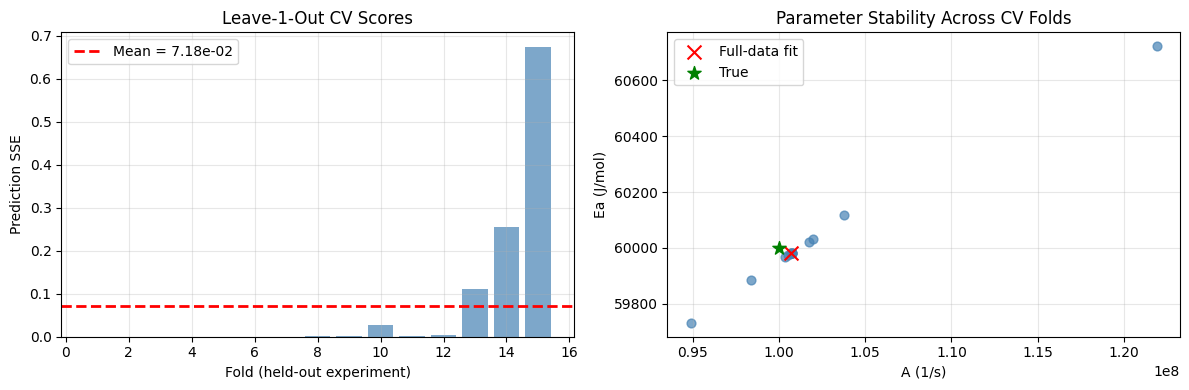

In [11]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CV scores
axes[0].bar(range(1, cv_result.n_folds + 1), cv_result.cv_scores, color='steelblue', alpha=0.7)
axes[0].axhline(cv_result.mean_score, color='red', linestyle='--', lw=2, label=f'Mean = {cv_result.mean_score:.2e}')
axes[0].set_xlabel('Fold (held-out experiment)')
axes[0].set_ylabel('Prediction SSE')
axes[0].set_title('Leave-1-Out CV Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fold-to-fold parameter stability
A_folds = [p['A'] for p in cv_result.fold_params]
Ea_folds = [p['Ea'] for p in cv_result.fold_params]
axes[1].scatter(A_folds, Ea_folds, s=40, alpha=0.7, color='steelblue')
axes[1].scatter([result.theta_opt['A']], [result.theta_opt['Ea']],
                color='red', s=100, marker='x', zorder=5, label='Full-data fit')
axes[1].scatter([A_true], [Ea_true], color='green', s=100, marker='*',
                zorder=5, label='True')
axes[1].set_xlabel('A (1/s)')
axes[1].set_ylabel('Ea (J/mol)')
axes[1].set_title('Parameter Stability Across CV Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Model Comparison with AIC/BIC

When choosing between competing models (e.g., first-order vs second-order kinetics),
AIC and BIC balance fit quality against model complexity.

- **AIC** = $n \ln(\text{SSR}/n) + 2k$ — penalizes by number of parameters
- **BIC** = $n \ln(\text{SSR}/n) + k \ln(n)$ — stronger penalty for large datasets

Lower is better.

In [12]:
# Generate data from a 2nd-order model: y = a*x^2 + b*x + c
rng = np.random.default_rng(55)
a_true, b_true_q, c_true = 0.5, 2.0, 1.0
x_data = np.linspace(0.5, 5.0, 20)

quad_experiments = []
for x in x_data:
    y = a_true * x**2 + b_true_q * x + c_true + 0.5 * rng.standard_normal()
    quad_experiments.append(Experiment(
        inputs={'x': float(x)},
        observed={'y': float(y)},
    ))

# Model 1: Linear (underfitting)
def model_linear(theta, exp):
    return {'y': theta['a'] * exp.inputs['x'] + theta['b']}

# Model 2: Quadratic (correct)
def model_quad(theta, exp):
    x = exp.inputs['x']
    return {'y': theta['a'] * x**2 + theta['b'] * x + theta['c']}

# Model 3: Cubic (overfitting)
def model_cubic(theta, exp):
    x = exp.inputs['x']
    return {'y': theta['a'] * x**3 + theta['b'] * x**2 + theta['c'] * x + theta['d']}

# Fit all three
est1 = Estimator(model_linear, ['a', 'b'])
est2 = Estimator(model_quad, ['a', 'b', 'c'])
est3 = Estimator(model_cubic, ['a', 'b', 'c', 'd'])

r1 = est1.fit(quad_experiments, {'a': 1.0, 'b': 0.0})
r2 = est2.fit(quad_experiments, {'a': 0.1, 'b': 1.0, 'c': 0.0})
r3 = est3.fit(quad_experiments, {'a': 0.01, 'b': 0.1, 'c': 1.0, 'd': 0.0})

d1 = est1.diagnostics(r1, quad_experiments)
d2 = est2.diagnostics(r2, quad_experiments)
d3 = est3.diagnostics(r3, quad_experiments)

print(f"{'Model':<12} {'N params':>10} {'R²':>10} {'RMSE':>10} {'AIC':>10} {'BIC':>10}")
print("-" * 62)
for name, diag in [('Linear', d1), ('Quadratic', d2), ('Cubic', d3)]:
    print(f"{name:<12} {diag.n_params:>10} {diag.r_squared:>10.6f} "
          f"{diag.rmse:>10.4f} {diag.aic:>10.2f} {diag.bic:>10.2f}")

print()
# Find best model
aics = {'Linear': d1.aic, 'Quadratic': d2.aic, 'Cubic': d3.aic}
best = min(aics, key=aics.get)
print(f"Best model by AIC: {best}")

Model          N params         R²       RMSE        AIC        BIC
--------------------------------------------------------------
Linear                2   0.981248     0.9055       0.03       2.02
Quadratic             3   0.991898     0.5952     -14.75     -11.77
Cubic                 4   0.992005     0.5913     -13.02      -9.04

Best model by AIC: Quadratic


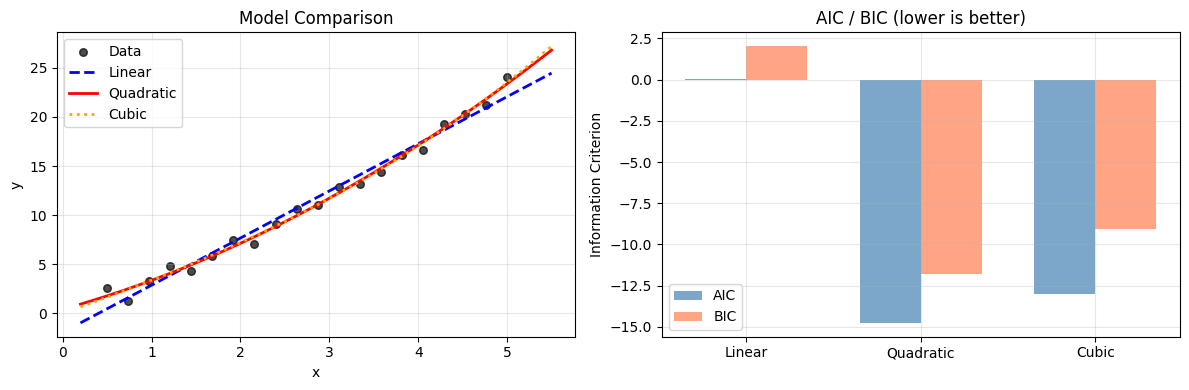

In [13]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_plot = np.linspace(0.2, 5.5, 200)

axes[0].scatter([e.inputs['x'] for e in quad_experiments],
                [e.observed['y'] for e in quad_experiments],
                label='Data', s=30, alpha=0.7, color='black')

# Plot each model
for name, res, est_obj, color, ls in [
    ('Linear', r1, est1, 'blue', '--'),
    ('Quadratic', r2, est2, 'red', '-'),
    ('Cubic', r3, est3, 'orange', ':'),
]:
    y_plot = []
    for x in x_plot:
        fake_exp = Experiment(inputs={'x': float(x)}, observed={'y': 0.0})
        p = est_obj.model_fn(res.theta_opt, fake_exp)
        y_plot.append(float(p['y']))
    axes[0].plot(x_plot, y_plot, color=color, linestyle=ls, lw=2, label=name)

axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Model Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AIC/BIC comparison
models = ['Linear', 'Quadratic', 'Cubic']
aic_vals = [d1.aic, d2.aic, d3.aic]
bic_vals = [d1.bic, d2.bic, d3.bic]
x_pos = np.arange(3)
width = 0.35

axes[1].bar(x_pos - width/2, aic_vals, width, label='AIC', color='steelblue', alpha=0.7)
axes[1].bar(x_pos + width/2, bic_vals, width, label='BIC', color='coral', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Information Criterion')
axes[1].set_title('AIC / BIC (lower is better)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

### When to Use Each Method

| Method | Use Case | Assumptions |
|--------|----------|-------------|
| **Fisher CI** | Quick CIs, large datasets | Normal errors, locally linear model |
| **Nonparametric Bootstrap** | Few assumptions needed, small data | None (distribution-free) |
| **Parametric Bootstrap** | Want to preserve input design | Residual structure representative |
| **Leave-N-Out CV** | Assess prediction ability | Training set representative |
| **AIC/BIC** | Choose between models | Models correctly specified |

### Key API

```python
est = Estimator(model, param_names, param_bounds)
result = est.fit(experiments, theta_init)

# Uncertainty quantification
ci = est.confidence_intervals(result, experiments)  # Fisher (fast)
bs = est.bootstrap(result, experiments, n_bootstrap=200)  # Bootstrap

# Predictive assessment
cv = est.cross_validate(experiments, theta_init, n=1)  # Leave-1-out

# Model comparison
diag = est.diagnostics(result, experiments)  # R², AIC, BIC
```